In [ ]:
from google.colab import drive
import os

# Check if Google Drive is already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print('/content/drive already exists, skipping drive.mount()')


/content/drive already exists, skipping drive.mount()


In [18]:
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import gc
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_PATH = '/content/drive/MyDrive/embeddings_assignment/processed_data/'

In [22]:
class NERDataset(Dataset):
    def __init__(self, data, vocab=None):
        self.sentences = data['tokens']; self.tags = data['tags']
        self.vocab = {'<PAD>': 0, '<UNK>': 1} if vocab is None else vocab
        if vocab is None:
            for s in self.sentences:
                for t in s:
                    if t not in self.vocab: self.vocab[t] = len(self.vocab)
    def __len__(self): return len(self.sentences)
    def __getitem__(self, idx):
        return torch.tensor([self.vocab.get(t, self.vocab['<UNK>']) for t in self.sentences[idx]]), torch.tensor(self.tags[idx])

In [23]:
def collate_fn(batch):
    s, t = zip(*batch)
    return pad_sequence(s, batch_first=True, padding_value=0), pad_sequence(t, batch_first=True, padding_value=-100)

In [24]:
class GloVeBiLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, target_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim // 2, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim, target_size)
    def forward(self, x): return self.fc(self.lstm(self.embedding(x))[0])

In [25]:
tokenizers = ['whitespace', 'nltk', 'wordpiece']
TAG_LABELS = ['O', 'B-Disease', 'I-Disease']

In [26]:
import os
root="/content/drive/MyDrive/embeddings_assignment"
OUTPUT_DIR = os.path.join(root, 'Glove_pipeline_results')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output will be saved in: {OUTPUT_DIR}")

Output will be saved in: /content/drive/MyDrive/embeddings_assignment/Glove_pipeline_results



================ RUNNING: GLOVE + WHITESPACE ================


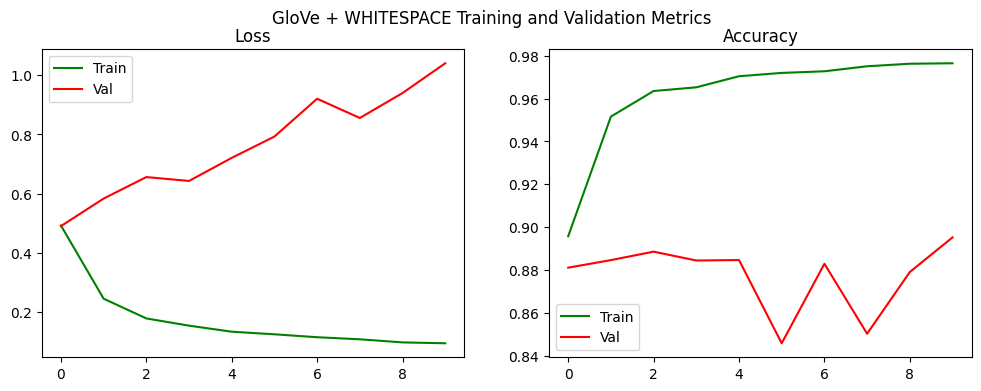

              precision    recall  f1-score   support

           O       0.99      0.90      0.94    117589
   B-Disease       0.27      0.85      0.41      4424
   I-Disease       0.41      0.63      0.50      2737

    accuracy                           0.89    124750
   macro avg       0.56      0.79      0.62    124750
weighted avg       0.95      0.89      0.92    124750



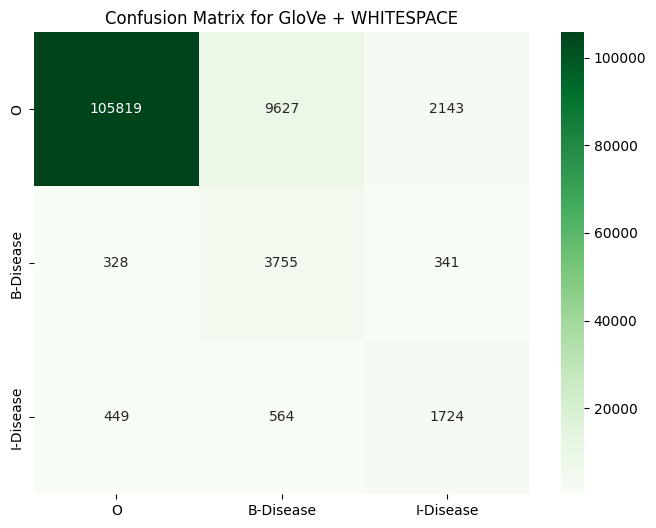


================ RUNNING: GLOVE + NLTK ================


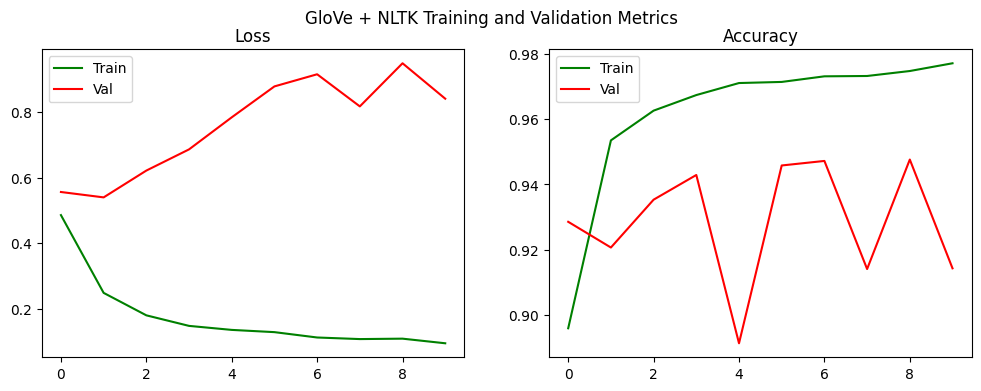

              precision    recall  f1-score   support

           O       0.99      0.93      0.96    117595
   B-Disease       0.47      0.71      0.57      4424
   I-Disease       0.23      0.69      0.34      2737

    accuracy                           0.91    124756
   macro avg       0.56      0.78      0.62    124756
weighted avg       0.96      0.91      0.93    124756



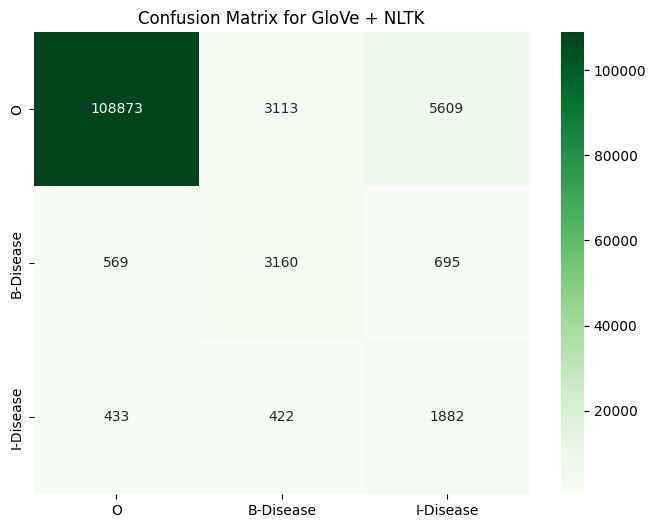


================ RUNNING: GLOVE + WORDPIECE ================


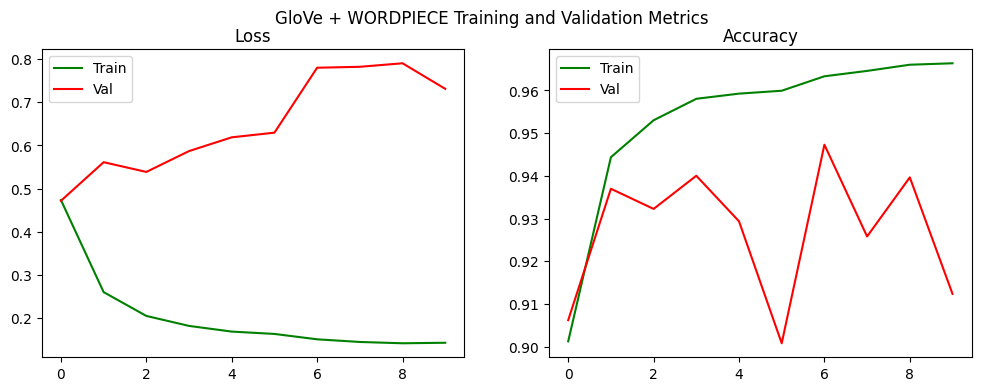

              precision    recall  f1-score   support

           O       0.99      0.92      0.96    117589
   B-Disease       0.42      0.78      0.54      4424
   I-Disease       0.28      0.70      0.40      2737

    accuracy                           0.91    124750
   macro avg       0.56      0.80      0.63    124750
weighted avg       0.96      0.91      0.93    124750



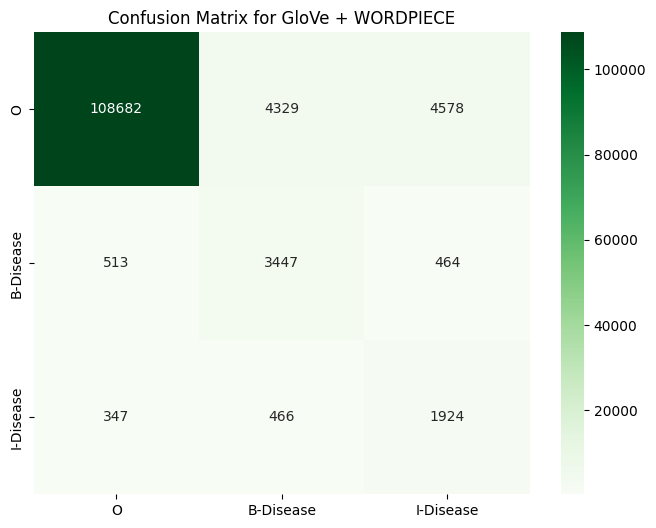

In [28]:
for tok in tokenizers:
    print(f"\n================ RUNNING: GLOVE + {tok.upper()} ================")
    with open(f'{BASE_PATH}train_{tok}.pkl', 'rb') as f: train_pkl = pickle.load(f)
    with open(f'{BASE_PATH}val_{tok}.pkl', 'rb') as f: val_pkl = pickle.load(f)
    with open(f'{BASE_PATH}test_{tok}.pkl', 'rb') as f: test_pkl = pickle.load(f)

    train_dataset = NERDataset(train_pkl)
    val_dataset = NERDataset(val_pkl, vocab=train_dataset.vocab)
    test_dataset = NERDataset(test_pkl, vocab=train_dataset.vocab)

    train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

    # Calculate Weights
    flat_tags = [t for tags in train_pkl['tags'] for t in tags if t != -100]
    class_counts = np.bincount(flat_tags, minlength=len(TAG_LABELS))
    class_counts = np.where(class_counts == 0, 1, class_counts)
    class_weights = sum(class_counts) / (len(TAG_LABELS) * class_counts)
    class_weights_tensor = torch.FloatTensor(class_weights).to(device)

    model = GloVeBiLSTM(len(train_dataset.vocab), 300, 128, len(TAG_LABELS)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, ignore_index=-100)

    t_loss, v_loss, t_acc, v_acc = [], [], [], []
    for epoch in range(10):
        model.train()
        loss_val, ok, tot = 0, 0, 0
        for seqs, tags in train_loader:
            seqs, tags = seqs.to(device), tags.to(device)
            optimizer.zero_grad()
            out = model(seqs)
            loss = criterion(out.view(-1, out.shape[-1]), tags.view(-1))
            loss.backward()
            optimizer.step()
            loss_val += loss.item()
            preds = torch.argmax(out, dim=-1)
            mask = tags != -100
            ok += (preds[mask] == tags[mask]).sum().item()
            tot += mask.sum().item()

        model.eval()
        v_loss_val, v_ok, v_tot = 0, 0, 0
        with torch.no_grad():
            for seqs, tags in val_loader:
                seqs, tags = seqs.to(device), tags.to(device)
                out = model(seqs)
                loss = criterion(out.view(-1, out.shape[-1]), tags.view(-1))
                v_loss_val += loss.item()
                preds = torch.argmax(out, dim=-1)
                mask = tags != -100
                v_ok += (preds[mask] == tags[mask]).sum().item()
                v_tot += mask.sum().item()

        t_loss.append(loss_val/len(train_loader)); t_acc.append(ok/max(1,tot))
        v_loss.append(v_loss_val/len(val_loader)); v_acc.append(v_ok/max(1,v_tot))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(t_loss, 'g-', label='Train'); ax1.plot(v_loss, 'r-', label='Val'); ax1.set_title('Loss'); ax1.legend()
    ax2.plot(t_acc, 'g-', label='Train'); ax2.plot(v_acc, 'r-', label='Val'); ax2.set_title('Accuracy'); ax2.legend()
    plt.suptitle(f'GloVe + {tok.upper()} Training and Validation Metrics')
    plt.savefig(os.path.join(OUTPUT_DIR, f'metrics_glove_{tok}.png'))
    plt.show()
    plt.close(fig)

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for seqs, tags in test_loader:
            seqs = seqs.to(device)
            preds = torch.argmax(model(seqs), dim=-1).cpu()
            mask = tags != -100
            y_true.extend(tags[mask].tolist()); y_pred.extend(preds[mask].tolist())

    report = classification_report(y_true, y_pred, target_names=TAG_LABELS, labels=range(len(TAG_LABELS)), zero_division=0)
    print(report)
    with open(os.path.join(OUTPUT_DIR, f'classification_report_glove_{tok}.txt'), 'w') as f:
        f.write(f'Classification Report for GloVe + {tok.upper()}:\n\n')
        f.write(report)

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_true, y_pred, labels=range(len(TAG_LABELS))), annot=True, fmt='d', cmap='Greens', xticklabels=TAG_LABELS, yticklabels=TAG_LABELS)
    plt.title(f'Confusion Matrix for GloVe + {tok.upper()}')
    plt.savefig(os.path.join(OUTPUT_DIR, f'confusion_matrix_glove_{tok}.png'))
    plt.show()
    plt.close('all')

    del model, train_loader, val_loader, test_loader
    gc.collect(); torch.cuda.empty_cache()